<a href="https://colab.research.google.com/github/barbararolska/Wizualizacja-danych/blob/main/Laboratorium6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wstęp do bibliotek Pandas oraz Seaborn

Do tej pory pracowaliśmy głównie w **Matplotlib**, ucząc się podstaw rysowania oraz filozofii oszczędności formy (Data-Ink Maximization). Dzisiaj poznamy **Seaborn** – bibliotekę zbudowaną na bazie Matplotlib, która jest ściśle zintegrowana ze strukturami danych biblioteki **Pandas**.

**Dlaczego Seaborn?**
- **Piękne domyślne style:** Wykresy wyglądają nowocześnie "z pudełka".
- **Integracja z DataFrame:** Nie musimy wyciągać kolumn do osobnych list – Seaborn sam rozumie ramki danych (wspiera format *[tidy data](https://aeturrell.github.io/python4DS/data-tidy.html#:~:text=6.2.%20Tidy,below%20shows%20this%3A)*).
- **Statystyka pod maską:** Seaborn automatycznie wykonuje agregacje przy rysowaniu wykresów (np. liczy średnią i dodaje przedziały ufności).

---

## 1. Przygotowanie danych z GitHuba

Będziemy korzystać z danych dostępnych w [repozytorium na Githubie Maćka Tadeja](https://github.com/tadejow/warsztaty-wizualizacja-danych/tree/main/data). To są prawdziwe dane zdobyte z różnorakich stron internetowych (*data scraping*)

Twoim zadaniem jest pobranie obowiązkowych plików `happiness_index.csv` oraz `world_data.csv`, a także **jednego dowolnego innego zbioru danych** z tego repozytorium. Ten ostatni zbiór danych będzie nam służył do analizy czynników powodujących, że ludzie są szczęśliwi.

**Jak poprawnie pobrać dane z repozytorium do notatnika?**
1. Wejdź na GitHuba, otwórz wybrany plik `.csv`.
2. W prawym górnym rogu podglądu pliku kliknij przycisk **"Raw"**.
3. Skopiuj adres URL z paska przeglądarki (musi zaczynać się od `https://raw.githubusercontent.com/...`).

**Instrukcja krok po kroku:**
1. Zaimportuj biblioteki: `pandas as pd`, `seaborn as sns` oraz `matplotlib.pyplot as plt`.
2. Ustaw domyślny, estetyczny styl Seaborna wywołując funkcję `sns.set_theme(style="whitegrid")`.
3. Stwórz trzy zmienne tekstowe (np. `url_happiness`, `url_world`, `url_trzecia`) i przypisz do nich skopiowane linki "Raw".
4. Wczytaj wszystkie trzy tabele do obiektów DataFrame za pomocą funkcji `pd.read_csv()`, przypisując je do zmiennych: `df_happiness`, `df_world`, `df_extra`.
5. Użyj metody `.head()` na wybranej tabeli, by podejrzeć jej strukturę. Podaj jako argument liczbę 3, aby wyświetlić trzy pierwsze wiersze tej tabeli.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
url_happiness = 'https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/refs/heads/main/data/happiness_index.csv'
url_world = 'https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/refs/heads/main/data/world_data.csv'
url_health = 'https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/refs/heads/main/data/health_index.csv'

df_happiness = pd.read_csv(url_happiness)
df_world = pd.read_csv(url_world)
df_extra = pd.read_csv(url_health)

df_happiness.head(3)


,year,country,rank,life evaluation,change (since 2012),inequality,social support,gdp per capita,healthy life expectancy,freedom,generosity,perceptions of corruption,positive emotions,negative emotions,donated,volunteered,helped a stranger,healthy life expectancy (2021 data)
0,2011,Denmark,1,7.856,NaN,11,4,9,22.0,9.0,7,3.0,16,29.0,7,45.0,45,NaN
1,2011,Finland,2,7.579,NaN,17,12,15,23.0,7.0,22,7.0,47,50.0,22,31.0,29,NaN
2,2011,Netherlands,4,7.512,NaN,2,11,6,NaN,14.0,3,10.0,18,37.0,3,15.0,48,NaN


In [2]:
df_extra.head(3)

,rank,country,health_care_index,health_care_exp_index,Year
0,1,Japan,96.1,179.4,2012
1,2,Indonesia,94.1,175.0,2012
2,3,Sri Lanka,93.5,174.2,2012


## 2. Manipulacja, czyszczenie i łączenie danych (Pandas)

Zanim narysujemy wykresy, przygotujemy nasze dane: wybierzemy interesujące nas kolumny, połączymy zbiory i naprawimy typy danych. Na koniec zajmiemy się brakami (`NaN`).

---

**Instrukcja krok po kroku:**
1. **Standaryzacja:** Upewnij się, że nazwy kolumn kluczowych się zgadzają. W trzeciej tabeli zmień nazwę kolumny z rokiem na małe litery, używając `df_extra.rename(columns={'Year': 'year'}, inplace=True)`.
2. **Filtrowanie kolumn:**
   - Z `df_happiness` wybierz kolumny: `['country', 'year', 'life evaluation', 'gdp per capita', 'social support', 'healthy life expectancy']` i nadpisz zmienną `df_happiness`.
   - Z `df_world` wybierz tylko: `['country', 'Region', 'Population']` i nadpisz `df_world`.
   - Z `df_extra` wybierz `['country', 'year']` oraz wybraną przez Ciebie kolumnę numeryczną (np. `'price_to_income_ratio'`) i nadpisz `df_extra`.
3. **Łączenie (Merge):** Połącz tabele `df_happiness` oraz `df_extra` funkcją `pd.merge()`. Jako warunek podaj `on=['country', 'year']` oraz `how='inner'`. Wynik przypisz do zmiennej `df`. Następnie zaktualizuj `df`, dołączając do niego `df_world` (tutaj łączymy tylko po `on='country'`, również `how='inner'`).
4. **Naprawa typów danych:** Czasem w plikach `.csv` braki są oznaczone myślnikiem (`-`), przez co Pandas traktuje te kolumny jako tekst. Zautomatyzujemy naprawę za pomocą pętli `for col in df.columns:`. Wewnątrz dodaj warunek `if col not in ['country', 'Region']:`. Dla takich kolumn wywołaj `pd.to_numeric(df[col], errors='coerce')` i przypisz wynik do `df[col]`.
5. **Grupowa imputacja braków danych (Mądre wypełnianie NaN):**
   - Najpierw wybierzmy tylko kolumny z liczbami: stwórz zmienną `numeric_cols = df.select_dtypes(include='number').columns`.
   - Użyj pętli iterującej po tych kolumnach: `for col in numeric_cols:`.
   - Wewnątrz pętli wypełnij braki średnią, ale zgrupowaną po regionach! Użyj kodu: `df[col] = df[col].fillna(df.groupby('Region')[col].transform('mean'))`. Funkcja `transform('mean')` oblicza średnią dla każdego regionu i przypisuje ją w puste miejsca odpowiednich państw. **UWAGA: można to zrobić jeszcze mądrzej, np. grupując ze względu zarówno na region jak i rok**.
   - Na sam koniec, poza pętlą, dodaj bezpiecznik (gdyby cały region miał `NaN`): `df.fillna(df.mean(numeric_only=True), inplace=True)`.
6. Użyj metody `.sample()` na ostatecznej tabeli, by podejrzeć jej strukturę. Podaj jako argument liczbę 3, aby wyświetlić trzy losowe wiersze tej tabeli.

In [3]:
df_extra.rename(columns={'Year': 'year'}, inplace=True)
df_happiness = df_happiness[['country', 'year', 'life evaluation', 'gdp per capita', 'social support', 'healthy life expectancy']]
df_world = df_world[['country', 'Region', 'Population']]
df_extra = df_extra[['country', 'year', 'health_care_index']]
df = pd.merge(df_happiness, df_extra, on=['country', 'year'], how='inner')
df = pd.merge(df, df_world, on='country', how='inner')
for col in df.columns:
  if col not in ['country', 'Region']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
      df[col] = df[col].fillna(df.groupby('Region')[col].transform('mean'))
      df.fillna(df.mean(numeric_only=True), inplace=True)
df.sample(3)


,country,year,life evaluation,gdp per capita,social support,healthy life expectancy,health_care_index,Region,Population
336,Ukraine,2016,4.096,67.0,52.0,82.0,49.7,EUROPE & NORTHERN AMERICA,46710816
402,India,2017,4.190,104.0,137.0,102.0,69.2,ASIA,1095351995
332,Egypt,2016,4.735,79.0,85.0,90.0,46.6,AFRICA,78887007


## 3. Generowanie wykresów w bibliotece Seaborn

Nasze dane są teraz czyste i w idealnym formacie numerycznym. Odtworzymy kluczowe typy wykresów, dbając o pełną spójność wizualną: użyjemy jednej palety kolorów dla wszystkich wykresów, pokażemy przedziały ufności na wykresie liniowym i stworzymy jedną, globalną legendę dla całej figury.

---

**Instrukcja krok po kroku:**
1. Stwórz płótno poleceniem `fig = plt.figure(figsize=(20, 12))`. Zdefiniuj zmienną ze wspólną paletą, np. `wspolna_paleta = 'tab10'`. Trochę więcej o paletach w [dokumentacji seaborna](https://seaborn.pydata.org/tutorial/color_palettes.html)
2. **Wykres Punktowy (Scatter Plot):** Wywołaj `ax1 = plt.subplot(2, 3, 1)`. Użyj `sns.scatterplot()`. Podaj `data=df`, `x='gdp per capita'`, `y='life evaluation'`, `hue='Region'`, `palette=wspolna_paleta`, `s=60` i `alpha=0.7`.
3. **Pobranie legendy:** Aby stworzyć globalną legendę, pobierzemy ją z pierwszego wykresu. Wywołaj `handles, labels = ax1.get_legend_handles_labels()`, a następnie usuń lokalną legendę: `ax1.get_legend().remove()`.
4. **Wykres Liniowy (Line Plot):** Wywołaj `plt.subplot(2, 3, 2)`. Użyj `sns.lineplot(..., legend=False)`. Zastosuj te same kolumny i paletę co wcześniej. *Nie wyłączaj* cieni przedziałów ufności (nie dodawaj `errorbar=None`), aby pokazać rozrzut krajów w danym regionie!
5. **Histogram (Hist Plot):** Wywołaj `plt.subplot(2, 3, 4)`. Użyj `sns.histplot(data=df, x='life evaluation', kde=True, color='purple')`. Tutaj paleta nie jest potrzebna, bo nie dzielimy na regiony.
6. **Wykres Słupkowy (Bar Plot):** Wywołaj `plt.subplot(2, 3, 3)`. Użyj `sns.barplot()`. Ustaw `x='Region'`, `y='life evaluation'`, dodaj `hue='Region'`, `palette=wspolna_paleta` oraz `legend=False`. Usuń etykiety osi X poleceniem `plt.xticks([])`. Podając tam pustą listę nie wyświetlisz nic.
7. **Wykres Pudełkowy (Box Plot):** Wywołaj `plt.subplot(2, 3, 5)`. Użyj `sns.boxplot()` z argumentami `x`, `y`, `hue`, `palette=wspolna_paleta` i `legend=False`. Usuń etykiety osi X.
8. **Wykres Skrzypcowy (Violin Plot):** Wywołaj `plt.subplot(2, 3, 6)`. Użyj `sns.violinplot()` podając te same argumenty oraz `inner='quartile'`. Usuń etykiety osi X.

Na koniec dodaj globalną legendę poleceniem `fig.legend(handles, labels, loc='center right', title='Region', fontsize=12)`. Wywołaj `plt.tight_layout(pad=3.0, rect=[0, 0, 0.85, 1])` (parametr `rect` rezerwuje 15% miejsca po prawej na naszą globalną legendę!), a następnie `plt.show()`.

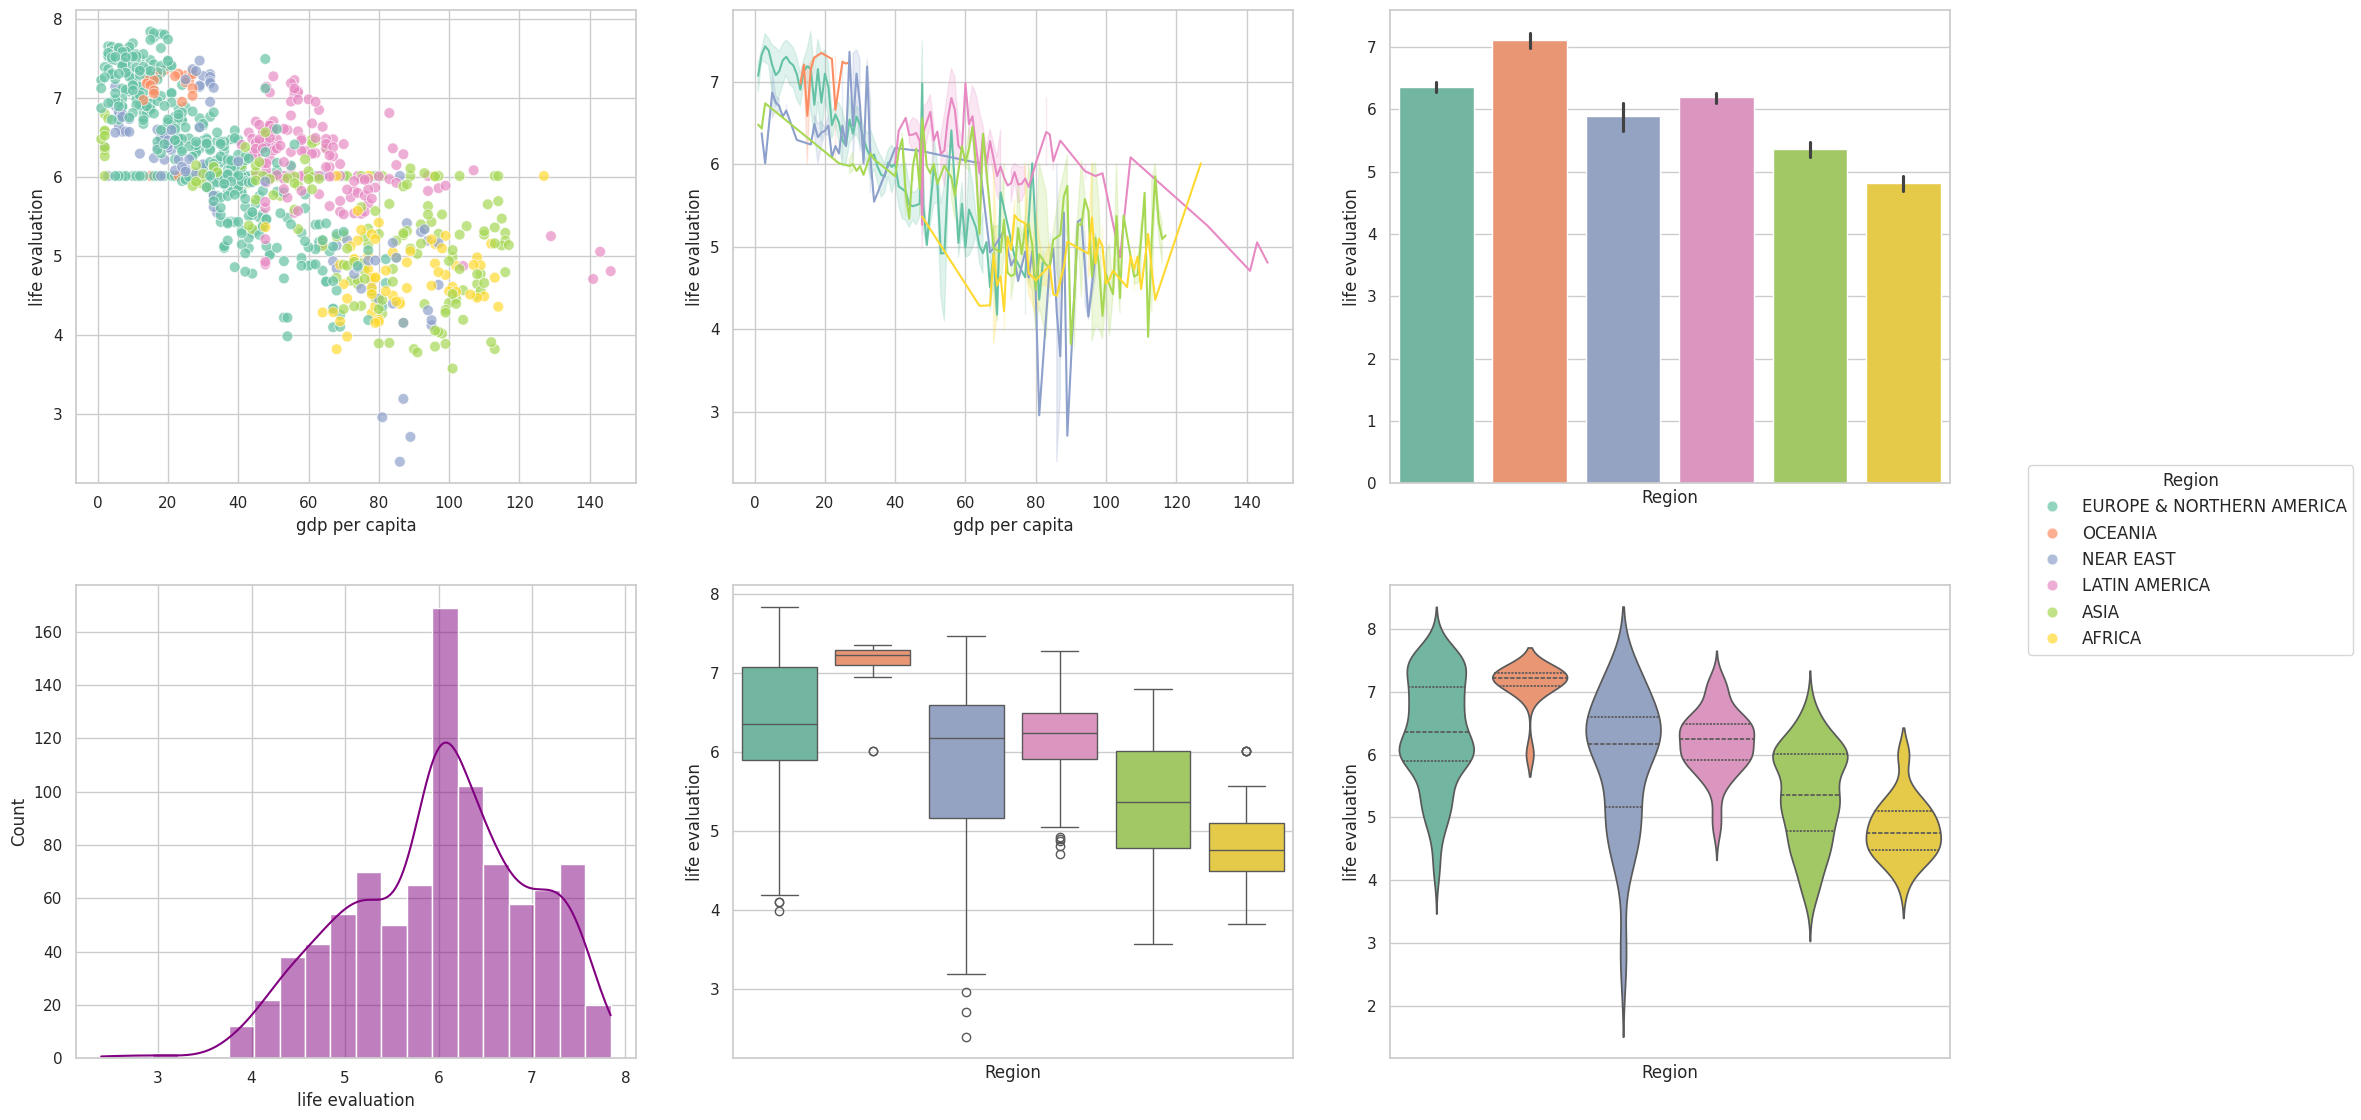

In [5]:
fig = plt.figure(figsize=(24, 12))
wspolna_paleta = "Set2"
ax1 = plt.subplot(2, 3, 1)
sns.scatterplot(data=df, x='gdp per capita', y='life evaluation', hue='Region', palette=wspolna_paleta, s=60, alpha=0.7)
handles, labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()
plt.subplot(2, 3, 2)
sns.lineplot(data=df, x='gdp per capita', y='life evaluation', hue='Region', palette=wspolna_paleta, legend=False)
plt.subplot(2, 3, 4)
sns.histplot(data=df, x='life evaluation', kde=True, color='purple')
plt.subplot(2, 3, 3)
sns.barplot(data=df, x='Region', y='life evaluation', hue='Region', palette=wspolna_paleta, legend=False)
plt.xticks([])
plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='Region', y='life evaluation', hue='Region', palette=wspolna_paleta, legend=False)
plt.xticks([])
plt.subplot(2, 3, 6)
sns.violinplot(data=df, x='Region', y='life evaluation', hue='Region', palette=wspolna_paleta, legend=False, inner='quartile')
plt.xticks([])
fig.legend(handles, labels, loc='center right', title='Region', fontsize=12)
plt.tight_layout(pad=3.0, rect=[0, 0, 0.85, 1])
plt.show()

## 4. Interpretacja wyników – co mówią nam te wykresy?

Samo narysowanie ładnych wykresów to dopiero połowa sukcesu. Jako analitycy danych, naszym zadaniem jest wyciągnięcie z nich wniosków (tzw. *insights*). Seaborn nie tylko ułatwia rysowanie, ale wręcz "myśli" za nas pod kątem statystycznym (co nie zawsze jest dobre!).

---

### ⚠️ Uwaga na dane rankingowe! (Pułapka interpretacyjna)
Zanim przejdziemy do wniosków, musimy zrozumieć strukturę naszych danych. W zbiorze `df_happiness` mamy do czynienia z dwoma różnymi sposobami zapisu informacji:
1. **Life Evaluation (Poczucie szczęścia):** To średnia z ocen w skali (0-10) dla danego kraju. **Im wyższa liczba, tym lepiej**.
2. **Pozostałe kolumny numeryczne (np. gdp per capita, social support):** To są **RANKINGI**.
   - Oznacza to, że wartość **1** oznacza państwo, które jest **najlepsze (najbogatsze)** w danej kategorii.
   - Wartość np. **140** oznacza państwo na szarym końcu zestawienia.

To wyjaśnia "odwrócony" kształt wykresu **Scatter Plot**: punkty o najwyższym poziomie szczęścia (wysoko na osi Y) znajdują się blisko zera na osi X (bo mają wysokie, czyli niskie numerowo, miejsce w rankingu bogactwa).

---

### "Magia" Seaborna: Agregacja i Przedziały Ufności
Spójrz na **Wykres Liniowy (Line Plot)** i **Słupkowy (Bar Plot)**. Dla każdego regionu (np. Europy) mamy przecież kilkadziesiąt państw każdego roku. Skąd Seaborn wiedział, jak narysować tylko jedną linię lub jeden słupek?
- **Automatyczna agregacja:** Seaborn domyślnie oblicza **średnią** ze wszystkich państw w danym regionie.
- **Przedział ufności (Confidence Interval):** Zauważyłeś ten półprzezroczysty cień wokół linii (oraz czarne pionowe kreski na środku słupków)? To właśnie 95% przedział ufności. Pokazuje on, na ile "pewna" jest ta średnia.
  - *Wąski cień* (np. dla Oceanii) oznacza, że kraje w tym regionie są bardzo do siebie podobne.
  - *Szeroki cień* oznacza duży rozrzut wewnątrz regionu (część państw jest bardzo szczęśliwa, a część bardzo nieszczęśliwa).

---

### Paradoks Oceanii i Europy (Bar Plot vs Box Plot)
Jeśli spojrzysz na wykres słupkowy, **Oceania** wydaje się absolutnym zwycięzcą – ma najwyższe średnie poczucie szczęścia. Jednak jeśli spojrzysz na **Box Plot**, zauważysz coś niesamowitego:
- Górny "wąs" (czyli najwyższa odnotowana wartość w historii) należy do **Europy i Ameryki Północnej (niebieski kolor)**. To tam żyją najszczęśliwsze narody na świecie (historycznie kraje skandynawskie: Finlandia, Dania).
- **Dlaczego więc Oceania wygrywa w średniej?** W Oceanii znajdują się w zasadzie tylko dwa państwa w tym zbiorze danych: Australia i Nowa Zelandia. Oba są bogate i stabilne. Europa z kolei to miks niezwykle szczęśliwej Skandynawii oraz znacznie mniej szczęśliwych państw Europy Wschodniej i Bałkanów. Te biedniejsze kraje zaniżają średnią dla całej Europy! To piękny przykład na to, dlaczego nigdy nie powinniśmy ufać samej średniej.

---

### Analityczne "Fun Facts" i Insighty:
1. **Zależność Bogactwo-Szczęście (Scatter Plot):** Pamiętając o rankingach, widzimy, że kraje z czołówki najbogatszych (blisko 0 na osi X) mają niemal gwarantowane wysokie szczęście. Jednak w miarę jak przesuwamy się w stronę biedniejszych państw (w stronę 140 na osi X), chmura punktów staje się znacznie bardziej "rozmyta" – bycie biednym nie zawsze oznacza bycie nieszczęśliwym.
2. **Latynoska radość życia:** Spójrz ponownie na Scatter Plot. Kraje Ameryki Łacińskiej (zielone kropki) często układają się wyraźnie wyżej niż wynikałoby to z ich rankingu PKB! Mimo niższych pozycji w rankingu zamożności, ich poziom szczęścia dorównuje krajom znacznie bogatszym.
3. **Nie jesteśmy idealnie normalni (Histogram i Violin Plot):** Zobacz, że rozkład szczęścia na świecie nie jest idealnie symetrycznym dzwonem (rozkładem normalnym). Jest lekko przesunięty w prawo – na świecie jest więcej ludzi umiarkowanie szczęśliwych (wyniki 5-7) niż absolutnie zdesperowanych (wyniki poniżej 3.5).
4. **Skrzypce mówią więcej niż pudełko:** Violin Plot dla Blieskiego Wschodu ma bardzo długą, "rozciągniętą" dolną część. Oznacza to, że choć większość krajów bliskowschodnich oscyluje wokół oceny 5-6, istnieje bardzo długi ogon państw z ekstremalnie niskim wskaźnikiem szczęścia (kraje dotknięte wojnami, skrajnym ubóstwem czy też fanatyzmem religijnym).

## 5. Zadania dla chętnych

Gdy profesjonalni analitycy danych dostają nowy zbiór, używają dwóch potężnych narzędzi, by szybko zrozumieć zależności między wieloma zmiennymi naraz. Są to **Korelogram (Heatmapa)** oraz **Wielowymiarowy wykres rozrzutu (Pairplot)**.

### Teoria: Jak czytać te wykresy?

**1. Heatmapa Korelacji (Korelogram):**
- **Co to jest?** To siatka, która kolorami pokazuje siłę zależności (korelację Pearsona) między wszystkimi zmiennymi liczbowymi.
- **Jak interpretować?** Wartości wahają się od -1 do 1. Wynik bliski **1** (często ciepłe kolory) oznacza silną korelację dodatnią (jedno rośnie to drugie też rośnie). Wynik bliski **-1** (zimne kolory) to korelacja ujemna (jedno rośnie, drugie maleje). Wynik w okolicach **0** to brak liniowego związku.
- **Kiedy używać?** Na samym początku analizy, aby błyskawicznie znaleźć, które zmienne w zbiorze danych najsilniej na siebie wpływają.

**2. Pairplot:**
- **Co to jest?** To matryca (macierz) wykresów. Na przekątnej pokazuje rozkłady pojedynczych zmiennych (np. histogramy lub linie gęstości), a na przecięciach – wykresy punktowe dla każdej możliwej pary zmiennych.
- **Jak interpretować?** Szukamy wzorców. Czy punkty układają się w chmury? Czy widać wyraźne linie (trendy)? Dzięki kolorowaniu punktów (`hue`) po kategorii (np. Regionie), możemy zobaczyć, czy kraje z danego kontynentu tworzą osobne skupiska.
- **Kiedy używać?** Gdy chcemy na jednym obrazku poszukać klastrów (skupisk), wartości odstających (outlierów) i wielowymiarowych zależności dla kliku najważniejszych cech.

---

**Instrukcja krok po kroku:**

W tym zadaniu wygenerujemy oba te wykresy jeden pod drugim, w dwóch komórkach z kodem (ponieważ `pairplot` jest tak rozbudowany, że sam tworzy własną wielką siatkę i nie zmieściłby się w zwykłym subplocie).

1. **Przygotowanie Korelogramu:**
   - Wyciągnij tylko liczbowe kolumny ze zbioru: stwórz zmienną `numeric_df = df.select_dtypes(include='number')`.
   - Oblicz korelacje: `corr_matrix = numeric_df.corr()`.
   - Stwórz okno wykresu `plt.figure(figsize=(23, 10))`.
   - Narysuj heatmapę wywołując `sns.heatmap()`. Jako argumenty podaj `corr_matrix`, a do ułatwienia odczytu dodaj `annot=True` (wyświetli liczby), `cmap='coolwarm'` (ciepłe/zimne barwy) oraz `fmt='.2f'` (zaokrąglenie do 2 miejsc po przecinku).
   - Wywołaj `plt.title()` i `plt.show()`, aby zamknąć i wyświetlić pierwszy wykres.

2. **Przygotowanie Pairplota:**
   - Wywołaj wielką matrycę poleceniem `sns.pairplot()`, podając `data=df` oraz `hue='Region'`. Możesz też dodać wybraną paletę, np. `palette='tab10'`.
   - Wyświetl całość używając `plt.show()`.

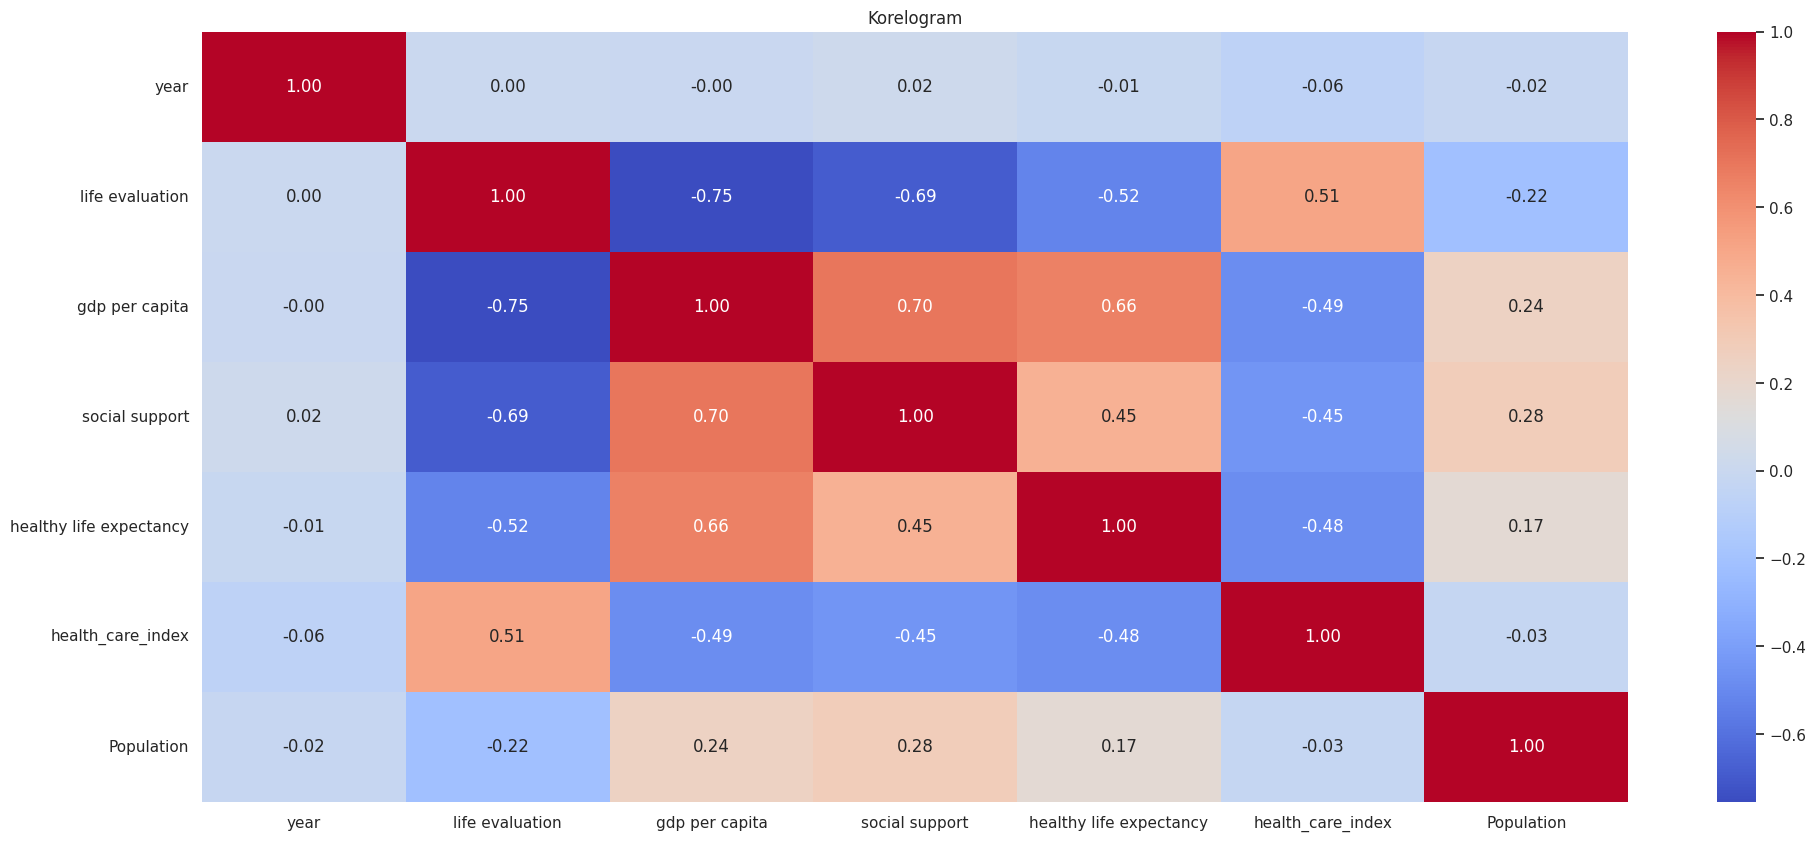

In [6]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
plt.figure(figsize=(23, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelogram')
plt.show()


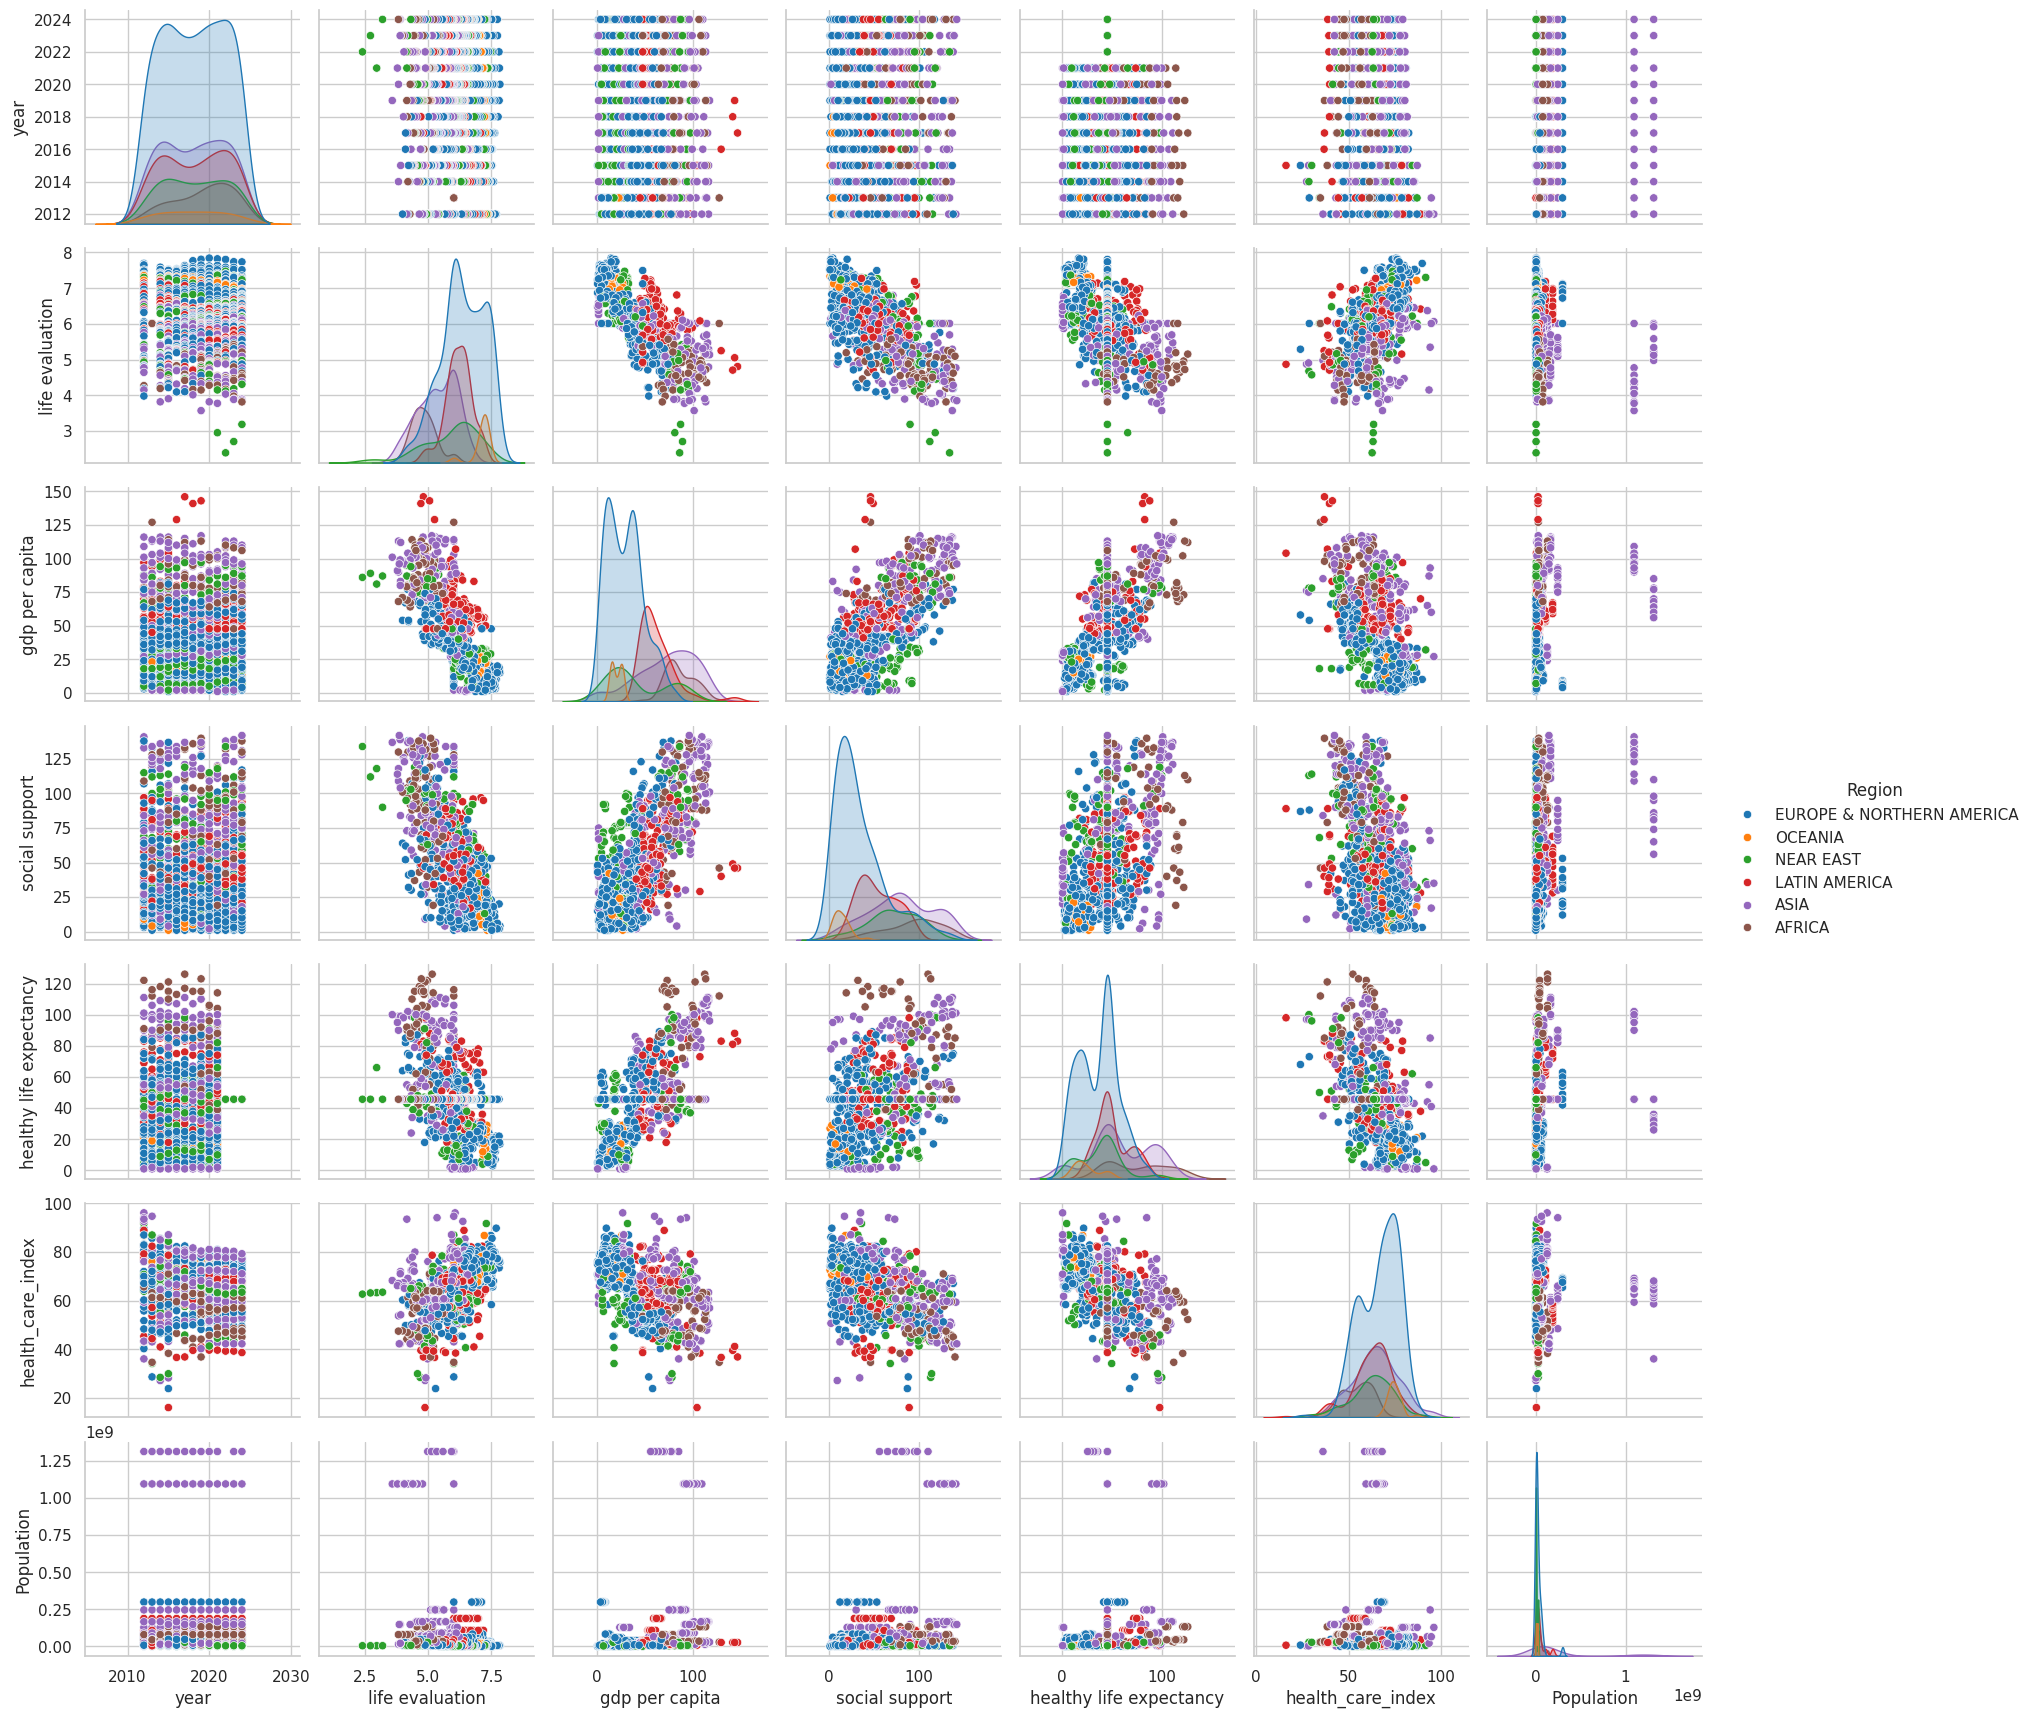

In [7]:
sns.pairplot(data=df, hue='Region', palette='tab10')
plt.show()